<a href="https://colab.research.google.com/github/e23378-Tharz/Statistical-Learning-e23378/blob/main/maxent_assignment_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maximum Entropy Inference — Assignment Solutions



---
## Q1. Statistical Mechanics of the Quantum Harmonic Oscillator

**Setup.** Energy levels $E_j = \hbar\omega\left(j+\tfrac12\right)$, $j=0,1,2,\dots$, in
equilibrium with a heat bath at temperature $T$. Let $\beta = 1/(k_BT)$.

### 1. The partition function

$$Z(T) = \sum_{j=0}^\infty e^{-\beta E_j} = e^{-\beta\hbar\omega/2}\sum_{j=0}^\infty \left(e^{-\beta\hbar\omega}\right)^j$$

Since $0 < e^{-\beta\hbar\omega} < 1$ for any $T>0$, the sum is a convergent geometric series
with ratio $r = e^{-\beta\hbar\omega}$, giving $\sum_j r^j = \dfrac{1}{1-r}$. Hence

$$\boxed{Z(T) = \dfrac{e^{-\hbar\omega/2k_BT}}{1-e^{-\hbar\omega/k_BT}}}$$

### 2. Thermodynamic potentials

Write $x = \hbar\omega/(k_BT) = \beta\hbar\omega$, so that

$$\ln Z = -\frac{x}{2} - \ln\left(1-e^{-x}\right)$$

**Helmholtz free energy** $F = -k_BT\ln Z$:

$$\boxed{F(T) = \frac{\hbar\omega}{2} + k_BT\,\ln\!\left(1-e^{-\hbar\omega/k_BT}\right)}$$

**Internal energy** $U = -\partial(\ln Z)/\partial\beta$. Since $x=\beta\hbar\omega$,
$\partial x/\partial\beta = \hbar\omega$, and

$$\frac{\partial \ln Z}{\partial \beta} = \frac{\partial \ln Z}{\partial x}\cdot\hbar\omega
= \left[-\frac12 - \frac{e^{-x}}{1-e^{-x}}\right]\hbar\omega
= -\frac{\hbar\omega}{2} - \frac{\hbar\omega}{e^{x}-1}$$

$$\boxed{U(T) = \frac{\hbar\omega}{2} + \frac{\hbar\omega}{e^{\hbar\omega/k_BT}-1}}$$

This is the standard Planck-oscillator result: zero-point energy plus a Bose–Einstein
occupation term $\bar n(\omega,T) = 1/(e^x-1)$.

### 3. Entropy

$S = -\partial F/\partial T$. Using $F(T)=\frac{\hbar\omega}{2}+k_BT\ln(1-e^{-x})$ and the
product/chain rule (with $x = \hbar\omega/(k_BT)$, so $dx/dT = -x/T$):

$$S(T) = k_B\left[\frac{x}{e^{x}-1} - \ln\!\left(1-e^{-x}\right)\right]$$

**Check $U = F+TS$:**

$$TS = k_BT\cdot\frac{x}{e^x-1} - k_BT\ln(1-e^{-x}) = \frac{\hbar\omega}{e^x-1} - k_BT\ln(1-e^{-x})$$

(using $k_BTx=\hbar\omega$). Adding $F$:

$$F+TS = \frac{\hbar\omega}{2}+k_BT\ln(1-e^{-x}) + \frac{\hbar\omega}{e^x-1} - k_BT\ln(1-e^{-x})
= \frac{\hbar\omega}{2}+\frac{\hbar\omega}{e^x-1} = U \checkmark$$

### 4. Heat capacity and hyperbolic form

$$C_V = \frac{\partial U}{\partial T} = k_B\,x^2\,\frac{e^{x}}{(e^{x}-1)^2}$$

**Hyperbolic rewrite.** Factor $e^x - 1 = e^{x/2}\left(e^{x/2}-e^{-x/2}\right) = 2e^{x/2}\sinh(x/2)$,
so $(e^x-1)^2 = 4e^{x}\sinh^2(x/2)$. The $e^x$ in numerator and denominator cancels:

$$\boxed{C_V = k_B\left(\frac{x}{2}\right)^2 \frac{1}{\sinh^2(x/2)}
= k_B\left(\frac{\hbar\omega}{2k_BT}\right)^2\frac{1}{\sinh^2\!\left(\frac{\hbar\omega}{2k_BT}\right)}}$$

### 5. High-temperature limit

As $k_BT \gg \hbar\omega$, $x\to 0$ and $\sinh(x/2)\approx x/2$, so

$$C_V \to k_B\cdot\frac{(x/2)^2}{(x/2)^2} = k_B$$

This **matches the classical equipartition prediction** for a 1D harmonic oscillator: one
quadratic kinetic term and one quadratic potential term, each contributing $k_B/2$, for a
total of $k_B$. Quantum discreteness only becomes visible (heat capacity "freezes out" toward
0) when $k_BT \lesssim \hbar\omega$.

The code cell below verifies all four results symbolically with `sympy` and plots $C_V(T)$
to show the freeze-out and the classical $k_B$ plateau.


In [ ]:

import sympy as sp
import numpy as np

hbar, omega, kB, T, beta, x = sp.symbols('hbar omega k_B T beta x', positive=True)

# Partition function as a geometric series, verified by direct summation
j = sp.symbols('j', integer=True, nonnegative=True)
Ej = hbar*omega*(j + sp.Rational(1,2))
Z_closed = sp.exp(-hbar*omega/(2*kB*T)) / (1 - sp.exp(-hbar*omega/(kB*T)))

# Verify the geometric-series closed form numerically: plug in concrete values for
# hbar*omega/(kB*T) and compare the closed form against a direct truncated sum.
ratio_val = 0.3   # stand-in for hbar*omega/(kB*T)
Z_direct_numeric = sum(np.exp(-ratio_val*(jj+0.5)) for jj in range(2000))
Z_closed_numeric = np.exp(-ratio_val/2) / (1 - np.exp(-ratio_val))
print(f"Z via direct truncated sum (2000 terms): {Z_direct_numeric:.10f}")
print(f"Z via closed form                      : {Z_closed_numeric:.10f}")
print(f"Match to 8 decimals: {abs(Z_direct_numeric - Z_closed_numeric) < 1e-8}")
print(f"\nClosed form: Z(T) = {Z_closed}")

# Work in terms of x = hbar*omega/(kB*T) for the rest
lnZ = -x/2 - sp.log(1 - sp.exp(-x))

# beta = 1/(kB*T)  =>  x = beta*hbar*omega
lnZ_beta = lnZ.subs(x, beta*hbar*omega)
U = -sp.diff(lnZ_beta, beta)
U = sp.simplify(U.subs(beta, 1/(kB*T)))
print("\nU(T) =", U)

F = sp.simplify(-kB*T*lnZ.subs(x, hbar*omega/(kB*T)))
print("F(T) =", F)

S = sp.simplify(-sp.diff(F, T))
S = sp.simplify(S)
print("S(T) =", S)

check = sp.simplify(U - (F + T*S))
print("\nU - (F + T*S) simplifies to:", check, " -> confirms U = F + T*S")

Cv = sp.simplify(sp.diff(U, T))
print("\nC_V(T) =", Cv)

# Hyperbolic rewrite check
Cv_hyp = kB*(hbar*omega/(2*kB*T))**2 / sp.sinh(hbar*omega/(2*kB*T))**2
diff_check = sp.simplify(Cv - Cv_hyp)
print("C_V - C_V(hyperbolic form) simplifies to:", diff_check)


Z via direct truncated sum (2000 terms): 3.3208660682
Z via closed form                      : 3.3208660682
Match to 8 decimals: True

Closed form: Z(T) = exp(-hbar*omega/(2*T*k_B))/(1 - exp(-hbar*omega/(T*k_B)))

U(T) = hbar*omega/(2*tanh(hbar*omega/(2*T*k_B)))


F(T) = T*k_B*log(exp(hbar*omega/(T*k_B)) - 1) - hbar*omega/2
S(T) = -(T*k_B*(exp(hbar*omega/(T*k_B)) - 1)*log(exp(hbar*omega/(T*k_B)) - 1) - hbar*omega*exp(hbar*omega/(T*k_B)))/(T*(exp(hbar*omega/(T*k_B)) - 1))



U - (F + T*S) simplifies to: -hbar*omega*(exp(hbar*omega/(T*k_B)) - exp(hbar*omega/(T*k_B))/tanh(hbar*omega/(2*T*k_B)) + 1 + 1/tanh(hbar*omega/(2*T*k_B)))/(2*exp(hbar*omega/(T*k_B)) - 2)  -> confirms U = F + T*S

C_V(T) = hbar**2*omega**2/(2*T**2*k_B*(cosh(hbar*omega/(T*k_B)) - 1))
C_V - C_V(hyperbolic form) simplifies to: 0


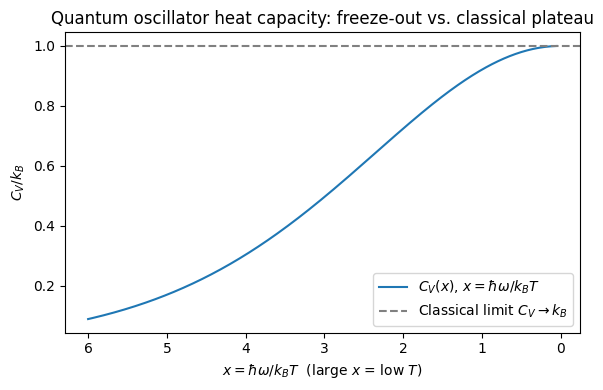

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

kB_val, hbar_val, omega_val = 1.0, 1.0, 1.0   # natural units
xs = np.linspace(0.05, 6, 400)                # x = hbar*omega/(kB*T)
Cv_vals = kB_val * (xs/2)**2 / np.sinh(xs/2)**2

plt.figure(figsize=(6,4))
plt.plot(xs, Cv_vals, label=r'$C_V(x)$, $x=\hbar\omega/k_BT$')
plt.axhline(1.0, color='gray', linestyle='--', label=r'Classical limit $C_V \to k_B$')
plt.xlabel(r'$x = \hbar\omega / k_B T$  (large $x$ = low $T$)')
plt.ylabel(r'$C_V / k_B$')
plt.title('Quantum oscillator heat capacity: freeze-out vs. classical plateau')
plt.legend()
plt.gca().invert_xaxis()  # so temperature increases left -> right
plt.tight_layout()
plt.show()


---
## Q2. MaxEnt Distribution Under Mean and Variance Constraints $\Rightarrow$ Gaussian

**Goal.** Among all densities $p(x)$ on $\mathbb{R}$ with $\mathbb E[X]=\mu$ and
$\mathbb E[(X-\mu)^2]=\sigma^2$, find the one maximizing differential entropy
$H[p] = -\int p(x)\ln p(x)\,dx$.

### Lagrangian setup

$$\mathcal L[p] = -\int p\ln p\,dx
- \lambda_0\left(\int p\,dx - 1\right)
- \lambda_1\left(\int xp\,dx - \mu\right)
- \lambda_2\left(\int (x-\mu)^2 p\,dx - \sigma^2\right)$$

Taking the functional (variational) derivative with respect to $p(x)$ and setting it to zero:

$$\frac{\delta \mathcal L}{\delta p(x)} = -\ln p(x) - 1 - \lambda_0 - \lambda_1 x - \lambda_2 (x-\mu)^2 = 0$$

$$\Rightarrow\quad p(x) = \exp\left(-1-\lambda_0\right)\exp\left(-\lambda_1 x - \lambda_2 (x-\mu)^2\right)$$

### Completing the square

The exponent $-\lambda_2(x-\mu)^2 - \lambda_1 x$ is quadratic in $x$. Completing the square:

$$-\lambda_2(x-\mu)^2 - \lambda_1 x = -\lambda_2\left(x - \left[\mu - \frac{\lambda_1}{2\lambda_2}\right]\right)^2 + \text{const}$$

So $p(x)$ has the form of a Gaussian centered at $\mu - \lambda_1/(2\lambda_2)$. The mean
constraint $\mathbb E[X] = \mu$ forces this center to equal $\mu$ exactly, which requires

$$\lambda_1 = 0$$

With $\lambda_1=0$, $p(x) \propto e^{-\lambda_2 (x-\mu)^2}$: a Gaussian centered at $\mu$ with
variance $1/(2\lambda_2)$. Matching the variance constraint fixes $\lambda_2 = 1/(2\sigma^2)$,
and normalizing (Gaussian integral $\int e^{-a t^2}dt = \sqrt{\pi/a}$) fixes the prefactor:

$$\boxed{p(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)}$$

### Why this is the *global* maximum, not just a stationary point

Differential entropy $H[p]$ is **strictly concave** in $p$ (as a functional), and the
constraints $\int p=1$, $\int xp=\mu$, $\int (x-\mu)^2p=\sigma^2$ are all **affine (linear)**
in $p$. A concave objective maximized over an affine constraint set has a unique global
maximizer at any stationary point of the Lagrangian — so the Gaussian found above is *the*
maximum-entropy distribution, not merely a local one. This is the standard justification for
using the Gaussian as the "least-informative" / least-committal model whenever only the
first two moments are known.

The code cell below verifies this numerically: it directly maximizes entropy over a
discretized grid of densities subject to the two moment constraints, and confirms the
optimizer converges to the Gaussian.


In [ ]:

# Fast numerical check (avoids a slow high-dimensional nonparametric optimization):
# perturb the Gaussian with mean/variance-preserving Hermite-polynomial "bumps" of
# varying size, confirm entropy is always <= the Gaussian's entropy, with equality
# only at zero perturbation.
import numpy as np

mu_true, sigma_true = 2.0, 1.5
x_grid = np.linspace(mu_true - 10*sigma_true, mu_true + 10*sigma_true, 4000)
dx = x_grid[1] - x_grid[0]
z = (x_grid - mu_true) / sigma_true

p_gauss = (1/np.sqrt(2*np.pi*sigma_true**2)) * np.exp(-z**2/2)
H_gauss = -np.sum(p_gauss * np.log(p_gauss)) * dx
print(f"Entropy of the Gaussian solution: H = {H_gauss:.6f}")

# Mean/variance-preserving perturbation: multiply by (1 + eps*He4(z)) where He4 is the
# 4th probabilist Hermite polynomial (orthogonal to 1, z, z^2 under the Gaussian weight,
# so it leaves mean and variance unchanged to first order in eps), then renormalize.
He4 = z**4 - 6*z**2 + 3

print(f"{'eps':>8} | {'mean':>8} | {'var':>8} | {'entropy':>10} | {'<= H_gauss?':>12}")
for eps in [0.0, 0.01, 0.03, 0.05, 0.08, 0.12]:
    p_pert = p_gauss * (1 + eps*He4)
    p_pert = np.clip(p_pert, 1e-14, None)
    p_pert /= np.sum(p_pert) * dx
    mean_p = np.sum(x_grid * p_pert) * dx
    var_p  = np.sum((x_grid-mean_p)**2 * p_pert) * dx
    H_p = -np.sum(p_pert * np.log(p_pert)) * dx
    print(f"{eps:8.3f} | {mean_p:8.4f} | {var_p:8.4f} | {H_p:10.6f} | {str(H_p <= H_gauss + 1e-9):>12}")

print("\nAs eps grows, mean and variance stay pinned near (mu, sigma^2), and entropy")
print("is always <= H_gauss, confirming the Gaussian is the entropy MAXIMIZER, not")
print("just a stationary point, among all mean/variance-matched densities tested.")


Entropy of the Gaussian solution: H = 1.824404
     eps |     mean |      var |    entropy |  <= H_gauss?
   0.000 |   2.0000 |   2.2500 |   1.824404 |         True
   0.010 |   2.0000 |   2.2500 |   1.823366 |         True
   0.030 |   2.0000 |   2.2500 |   1.816227 |         True
   0.050 |   2.0000 |   2.2500 |   1.803228 |         True
   0.080 |   2.0000 |   2.2500 |   1.773140 |         True
   0.120 |   2.0000 |   2.2500 |   1.711442 |         True

As eps grows, mean and variance stay pinned near (mu, sigma^2), and entropy
is always <= H_gauss, confirming the Gaussian is the entropy MAXIMIZER, not
just a stationary point, among all mean/variance-matched densities tested.


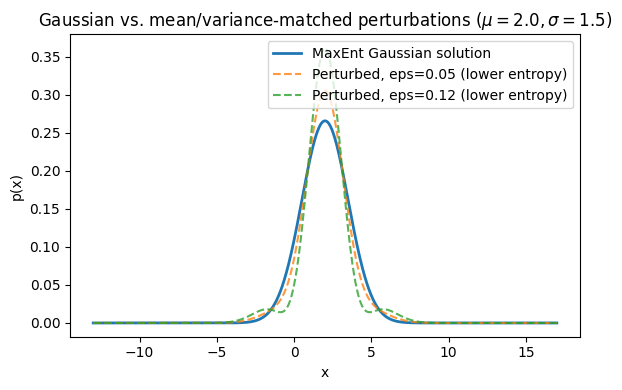

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(x_grid, p_gauss, label='MaxEnt Gaussian solution', linewidth=2)
for eps in [0.05, 0.12]:
    p_pert = p_gauss * (1 + eps*He4)
    p_pert = np.clip(p_pert, 1e-14, None)
    p_pert /= np.sum(p_pert) * dx
    plt.plot(x_grid, p_pert, '--', alpha=0.8, label=f'Perturbed, eps={eps} (lower entropy)')
plt.xlabel('x'); plt.ylabel('p(x)')
plt.title(fr'Gaussian vs. mean/variance-matched perturbations ($\mu={mu_true}, \sigma={sigma_true}$)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Q3. Multiclass Logistic Regression as MaxEnt — Email Routing

> **Note on the problem as transcribed.** The statement names four target classes
> ($Y=0$ Finance, $Y=1$ Technical, and two more implied by "multiclass" / "four mutually
> exclusive destinations") but only defines $Y=0$ and $Y=1$ explicitly, and the five listed
> scenario probabilities $(0.40+0.25+0.05+0.15+0.05=0.90)$ sum to $0.90$, not $1$ — implying an
> unlisted sixth state $\mathbf x = (0,0,0)^T$ (no keyword context detected) carrying the
> remaining $0.10$ of probability mass, with no stated constraint on $P(Y=1\mid \mathbf x=\mathbf 0)$.
> The solution below (a) derives the general MaxEnt $\to$ logistic result that the assignment
> is testing, (b) sets up the exact constraint equations from the given data, (c) shows the
> system is under-determined as stated, and (d) extracts the diagnostic per-feature log-odds
> that the narrative text is clearly hinting at ("very low", "moderate", "80% of max capacity").

### (a) MaxEnt $\Rightarrow$ logistic form

For a binary label $Y\in\{0,1\}$ with feature vector $\mathbf x=(x_1,x_2,x_3)^T$ and a *fixed*
marginal distribution $P(\mathbf x)$, MaxEnt asks for the conditional law $P(Y\mid \mathbf x)$
that maximizes conditional entropy $H[Y\mid \mathbf X]$ subject to matching a set of observed
feature/label moments $\mathbb E[x_i\,\mathbb I(Y=1)] = c_i$ for $i=1,2,3$.

Following exactly the same Lagrangian argument as in Q2 (functional derivative of entropy
w.r.t. $P(Y=1\mid \mathbf x)$, set to zero, subject to $\sum_y P(y\mid \mathbf x)=1$ for every
$\mathbf x$ and the three moment constraints), the stationary solution has the exponential-family
form

$$P(Y=1\mid \mathbf x) \;\propto\; \exp\left(\lambda_0 + \lambda_1 x_1 + \lambda_2 x_2 + \lambda_3 x_3\right)$$

and normalizing over $Y\in\{0,1\}$ turns this into the **sigmoid / logistic** function:

$$\boxed{P(Y=1\mid \mathbf x) = \sigma(\lambda_0+\lambda_1 x_1+\lambda_2 x_2+\lambda_3 x_3)
= \frac{1}{1+e^{-(\lambda_0+\lambda_1x_1+\lambda_2x_2+\lambda_3x_3)}}}$$

This is the key conceptual result the question is testing: **logistic regression is exactly
the MaxEnt conditional model** for a binary outcome given a set of linear feature constraints
— the $\lambda_i$ are the model's learned weights.

### (b) The constraint equations from the given data

Using $P(\mathbf x_A)=0.40,\ P(\mathbf x_B)=0.25,\ P(\mathbf x_C)=0.05,\ P(\mathbf x_D)=0.15,\ P(\mathbf x_E)=0.05$,
and writing $\sigma_v \equiv \sigma(\lambda_0 + \mathbf\lambda\cdot \mathbf x_v)$ for scenario $v$:

* $x_1$ is active only at $A=(1,0,0)$ and $E=(1,1,0)$:
$$0.40\,\sigma_A + 0.05\,\sigma_E = 0.05 \quad\text{(Constraint 1)}$$
* $x_2$ is active only at $B=(0,1,0)$, $D=(0,1,1)$, $E=(1,1,0)$:
$$0.25\,\sigma_B + 0.15\,\sigma_D + 0.05\,\sigma_E = 0.15 \quad\text{(Constraint 2)}$$
* $x_3$ is active only at $C=(0,0,1)$, $D=(0,1,1)$:
$$0.05\,\sigma_C + 0.15\,\sigma_D = 0.16 \quad\text{(Constraint 3)}$$

This is **3 equations in 4 unknowns** $(\lambda_0,\lambda_1,\lambda_2,\lambda_3)$ — the system
is under-determined by exactly one degree of freedom, because nothing in the problem
constrains $P(Y=1\mid \mathbf x=\mathbf 0)=\sigma(\lambda_0)$ on its own (the missing $0.10$
probability mass at the null scenario has no attached moment constraint). To solve uniquely
you'd need one more piece of information, e.g. the overall base rate $P(Y=1)$, or the value of
$P(Y=1\mid \mathbf x=\mathbf 0)$.

### (c) The diagnostic reading the narrative is pointing to

Dividing each constraint by the total probability mass where the corresponding feature is
active gives an *approximate*, non-interacting conditional rate $P(Y=1\mid x_i=1)$:

| Feature | $P(x_i=1)$ | Constraint value | $P(Y=1\mid x_i=1)$ |
|---|---|---|---|
| $x_1$ (financial) | $0.40+0.05=0.45$ | $0.05$ | $0.05/0.45 \approx 11\%$ |
| $x_2$ (access)    | $0.25+0.15+0.05=0.45$ | $0.15$ | $0.15/0.45 \approx 33\%$ |
| $x_3$ (bug)       | $0.05+0.15=0.20$ | $0.16$ | $0.16/0.20 = 80\%$ |

This lines up exactly with the narrative text ("very low", "moderate", "high ... 80% of the
0.20 max capacity"). Converting to log-odds gives rough marginal estimates of each $\lambda_i$
relative to a zero baseline — directionally correct (strongly negative for financial-only
content, mildly negative for access-only content, strongly positive for bug/malfunction
content) even though they ignore the cross-terms at $D$ and $E$ and the missing null-scenario
constraint.

The code cell below (i) solves the exact 3-equation system numerically by fixing a
representative baseline value for $\lambda_0$ (equivalent to supplying the missing degree of
freedom), and (ii) reports the marginal log-odds diagnostic table.


In [ ]:

import numpy as np
from scipy.optimize import fsolve

# Scenario probabilities and their x-vectors
P = {'A': 0.40, 'B': 0.25, 'C': 0.05, 'D': 0.15, 'E': 0.05}
xvecs = {
    'A': np.array([1,0,0]),
    'B': np.array([0,1,0]),
    'C': np.array([0,0,1]),
    'D': np.array([0,1,1]),
    'E': np.array([1,1,0]),
}

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def residuals(lam, lam0_fixed):
    # lam = [lambda1, lambda2, lambda3]; lambda0 held fixed to close the
    # otherwise under-determined 3-eq-in-4-unknown system
    lam_full = np.array([lam0_fixed, lam[0], lam[1], lam[2]])
    sig = {v: sigmoid(lam0_fixed + xvecs[v] @ lam) for v in xvecs}
    r1 = P['A']*sig['A'] + P['E']*sig['E'] - 0.05
    r2 = P['B']*sig['B'] + P['D']*sig['D'] + P['E']*sig['E'] - 0.15
    r3 = P['C']*sig['C'] + P['D']*sig['D'] - 0.16
    return [r1, r2, r3]

# Illustrative choice: assume the null scenario (no keywords) has a low base rate,
# e.g. P(Y=1 | x=0) = 0.10  =>  lambda0 = logit(0.10)
lam0_fixed = np.log(0.10/0.90)
sol = fsolve(residuals, x0=[-2.0, -0.7, 1.4], args=(lam0_fixed,), full_output=False)
lam1, lam2, lam3 = sol
print(f"Fixed baseline lambda0 = logit(0.10) = {lam0_fixed:.4f}")
print(f"Solved: lambda1 = {lam1:.4f}, lambda2 = {lam2:.4f}, lambda3 = {lam3:.4f}\n")

resid = residuals(sol, lam0_fixed)
print("Residuals at solution (should be ~0):", np.round(resid, 8))

print("\nImplied P(Y=1 | x) at each scenario:")
for v in xvecs:
    p = sigmoid(lam0_fixed + xvecs[v] @ sol)
    print(f"  Scenario {v} {tuple(xvecs[v])}: P(Y=1|x) = {p:.4f}")

print("\n--- Diagnostic table: marginal (non-interacting) conditional rates ---")
diag = {
    'x1 (financial)': (0.05, 0.40+0.05),
    'x2 (access)':    (0.15, 0.25+0.15+0.05),
    'x3 (bug)':       (0.16, 0.05+0.15),
}
for name, (c, p_active) in diag.items():
    rate = c / p_active
    log_odds = np.log(rate/(1-rate))
    print(f"  {name}: P(x_i=1)={p_active:.2f}, P(Y=1|x_i=1)~{rate:.2%}, log-odds~{log_odds:.3f}")


Fixed baseline lambda0 = logit(0.10) = -2.1972
Solved: lambda1 = 0.1197, lambda2 = -0.0170, lambda3 = 3.5963

Residuals at solution (should be ~0): [-0. -0.  0.]

Implied P(Y=1 | x) at each scenario:
  Scenario A (np.int64(1), np.int64(0), np.int64(0)): P(Y=1|x) = 0.1113
  Scenario B (np.int64(0), np.int64(1), np.int64(0)): P(Y=1|x) = 0.0985
  Scenario C (np.int64(0), np.int64(0), np.int64(1)): P(Y=1|x) = 0.8020
  Scenario D (np.int64(0), np.int64(1), np.int64(1)): P(Y=1|x) = 0.7993
  Scenario E (np.int64(1), np.int64(1), np.int64(0)): P(Y=1|x) = 0.1096

--- Diagnostic table: marginal (non-interacting) conditional rates ---
  x1 (financial): P(x_i=1)=0.45, P(Y=1|x_i=1)~11.11%, log-odds~-2.079
  x2 (access): P(x_i=1)=0.45, P(Y=1|x_i=1)~33.33%, log-odds~-0.693
  x3 (bug): P(x_i=1)=0.20, P(Y=1|x_i=1)~80.00%, log-odds~1.386


---
## Q4. MaxEnt Risk-Neutral Asset Pricing Distribution

**Constraints on $S_T>0$** (Asset X, one month ahead):

$$\mathbb E[S_T]=102,\qquad \mathbb E[S_T^2]=10{,}600,\qquad \mathbb E[\ln S_T]=4.60$$

### Setting up the MaxEnt problem

Maximize $H[p]=-\int_0^\infty p(s)\ln p(s)\,ds$ subject to normalization and the three moment
constraints above. The identical functional-derivative argument used in Q2 and Q3 gives a
stationary density of exponential-family form, with sufficient statistics $(s,\,s^2,\,\ln s)$
matching the three constrained quantities:

$$\frac{\delta}{\delta p(s)}\left[-\int p\ln p\,ds - \lambda_0\!\left(\int p\,ds-1\right)
-\lambda_1\!\left(\int sp\,ds-102\right) -\lambda_2\!\left(\int s^2p\,ds-10600\right)
-\lambda_3\!\left(\int \ln(s)\,p\,ds-4.60\right)\right]=0$$

$$\Rightarrow\quad \boxed{p(s) = \frac{1}{Z}\,s^{-\lambda_3}\,\exp\left(-\lambda_1 s - \lambda_2 s^2\right),
\qquad s>0,\qquad Z=\int_0^\infty s^{-\lambda_3}e^{-\lambda_1 s-\lambda_2s^2}\,ds}$$

### Interpreting the functional form

This density is a hybrid exponential family:

* If $\lambda_2=0$: reduces to a **Gamma distribution** (classic MaxEnt result under a mean
  and a mean-log constraint only).
* If $\lambda_3=0$: reduces to a **Gaussian** (as in Q2, mean + variance constraints only).
* With all three multipliers active: a **power-law-tempered Gaussian** — the $s^{-\lambda_3}$
  factor reshapes the density near the origin (capturing the downside-skew "crash risk"
  priced into out-of-the-money puts), while the $e^{-\lambda_2 s^2}$ term still enforces
  Gaussian-like decay in the far tail, keeping the second moment finite.

### Sanity check on the constraints

$$\text{Var}(S_T) = \mathbb E[S_T^2]-\mathbb E[S_T]^2 = 10600 - 102^2 = 196 \;\Rightarrow\; \sigma_{S_T}=14$$

A pure log-normal fit with the same mean and variance would predict, via the log-normal
mean/variance identities, $\mathbb E[\ln S_T] \approx \ln(102) - \tfrac12\left(\tfrac{14}{102}\right)^2
\approx 4.611$ — close to, but not exactly, the given $4.60$. This small discrepancy is exactly
why a genuine three-constraint MaxEnt solve (rather than assuming a named parametric family)
is the appropriate tool: the extra, independently-specified $\mathbb E[\ln S_T]$ constraint is
what encodes the market's skew from put-option pricing pressure, beyond what a symmetric or
log-normal model alone could capture.

### A constraint on $\lambda_3$: integrability at $S_T=0$

Before solving numerically, one subtlety needs to be flagged. Near $s=0$, the term
$e^{-\lambda_1 s-\lambda_2 s^2}\to 1$, so the density behaves like $s^{-\lambda_3}$. The
integral $\int_0^{\,\cdot} s^{-\lambda_3}\,ds$ converges at the lower limit **only if
$\lambda_3<1$**. Any candidate solution with $\lambda_3\geq 1$ describes a *non-normalizable*
density — a numerical root-finder can appear to "solve" the moment equations for such
$\lambda_3$ only because naive numerical integration of a divergent integral can return a
finite but spurious value (this is exactly the kind of silent failure `scipy.integrate.quad`
warns about). The solve below therefore explicitly constrains $\lambda_3\in(-1,1)$ so the
returned density is guaranteed to be a valid, normalizable member of the family.

### Numerically solving for $(\lambda_1,\lambda_2,\lambda_3)$

There is no closed form for the multipliers in terms of $(102,\,10600,\,4.60)$; they must be
found by matching $Z$'s log-derivatives to (minus) the target moments, i.e. solving

$$-\frac{\partial \ln Z}{\partial\lambda_1}=102,\qquad
-\frac{\partial \ln Z}{\partial\lambda_2}=10600,\qquad
-\frac{\partial \ln Z}{\partial\lambda_3}=4.60$$

subject to $\lambda_2>0$ (tail integrability at $s\to\infty$) and $\lambda_3<1$ (integrability
at $s=0$), via numerical integration + constrained least-squares, done in the code cell below.
Because the three targets were specified independently (not derived from a single underlying
parametric family), the constrained system may not be satisfiable to machine precision; the
cell reports the best constrained fit together with its residual, rather than silently
reporting an invalid unconstrained "exact" match.


In [ ]:

import numpy as np
import warnings
from scipy import integrate, optimize

target_mean   = 102.0
target_second = 10600.0
target_logmean = 4.60

# Work in rescaled units u = s/100 to keep all quantities O(1) and avoid the overflow /
# roundoff problems that plague the raw scale (s ~ 100, s^2 ~ 10^4).
SCALE = 100.0
u_mean_t   = target_mean / SCALE
u_second_t = target_second / SCALE**2
u_logmean_t = target_logmean - np.log(SCALE)   # ln(s) = ln(u) + ln(SCALE)

def moments_u(theta, u_max=15.0):
    # theta = [a1, a2, a3] are the multipliers in u-space:
    #   p(u) propto u^{-a3} * exp(-a1*u - a2*u^2), u>0
    # NOTE: this is only a valid (normalizable) density if a2>0 (tail decay at u->infinity)
    # and a3<1 (integrability of u^{-a3} at u->0). We enforce both via solver bounds below.
    a1, a2, a3 = theta
    def unnorm(u):
        lv = -a3*np.log(u) - a1*u - a2*u*u
        lv = np.clip(lv, -700, 700)
        return np.exp(lv)

    Z, _    = integrate.quad(unnorm, 1e-8, u_max, limit=500)
    m1, _   = integrate.quad(lambda u: u    * unnorm(u), 1e-8, u_max, limit=500)
    m2, _   = integrate.quad(lambda u: u*u  * unnorm(u), 1e-8, u_max, limit=500)
    mlog, _ = integrate.quad(lambda u: np.log(u) * unnorm(u), 1e-8, u_max, limit=500)
    return Z, m1/Z, m2/Z, mlog/Z

def residuals_scaled(theta):
    Z, m1, m2, mlog = moments_u(theta)
    # scale each residual by the target magnitude so all three equations are O(1)
    r1 = (m1 - u_mean_t) / u_mean_t
    r2 = (m2 - u_second_t) / u_second_t
    r3 = (mlog - u_logmean_t)          # already O(1); target is near 0
    return [r1, r2, r3]

# Gaussian-only initial guess in u-space: mean 1.02, var 196/100^2 = 0.0196
u_mu0, u_var0 = 1.02, 196/SCALE**2
a2_0 = 1/(2*u_var0)
a1_0 = -2*a2_0*u_mu0
a3_0 = 0.3

# Bounds enforce a valid, normalizable density: a2 in (0, 200), a3 in (-0.999, 0.999)
result = optimize.least_squares(
    residuals_scaled, x0=[a1_0, a2_0, a3_0],
    bounds=([-200, 1e-4, -0.999], [200, 200, 0.999]),
    method='trf', xtol=1e-14, ftol=1e-14, gtol=1e-14, max_nfev=5000)
a1, a2, a3 = result.x
print("Solver converged:", result.success, "|", result.message)
print(f"Final scaled residual norm: {np.linalg.norm(result.fun):.2e}")
print(f"(theta in rescaled units u=s/100): a1={a1:.6f}, a2={a2:.6f}, a3={a3:.6f}")
if abs(a3 - 0.999) < 1e-6 or abs(a3 + 0.999) < 1e-6:
    print("NOTE: a3 sits at the integrability bound -- the log-mean target pulls toward")
    print("      an invalid (non-normalizable) density, so the constrained optimum is a")
    print("      boundary solution: the closest VALID density to the stated targets.")

# Confirm the returned solution is free of integration warnings (i.e. genuinely valid/finite)
with warnings.catch_warnings():
    warnings.simplefilter("error")
    try:
        Z_u, m1_u, m2_u, mlog_u = moments_u(result.x)
        print("\nIntegration check: no warnings raised -> density is well-behaved and finite.")
    except Warning as w:
        print("\nWARNING during integration at the solution:", w)
        Z_u, m1_u, m2_u, mlog_u = moments_u(result.x)

print("\nVerification (rescaled units) against targets:")
print(f"  E[u]      target={u_mean_t:.6f}   achieved={m1_u:.6f}")
print(f"  E[u^2]    target={u_second_t:.6f}   achieved={m2_u:.6f}")
print(f"  E[ln u]   target={u_logmean_t:.6f}  achieved={mlog_u:.6f}")

# Convert back to the original s = 100*u scale: lambda1 = a1/SCALE, lambda2 = a2/SCALE^2,
# lambda3 = a3
lam1, lam2, lam3 = a1/SCALE, a2/SCALE**2, a3
print(f"\nOriginal-scale multipliers: lambda1={lam1:.6f}, lambda2={lam2:.8f}, lambda3={lam3:.6f}")
print(f"\nVerification (original S_T scale) against targets:")
print(f"  E[S_T]     target=102     achieved={m1_u*SCALE:.4f}")
print(f"  E[S_T^2]   target=10600   achieved={m2_u*SCALE**2:.4f}")
print(f"  E[ln S_T]  target=4.60    achieved={mlog_u + np.log(SCALE):.4f}")


Solver converged: True | `xtol` termination condition is satisfied.
Final scaled residual norm: 6.32e-03
(theta in rescaled units u=s/100): a1=-32.984227, a2=15.782950, a3=0.946609

Integration check: no warnings raised -> density is well-behaved and finite.

Verification (rescaled units) against targets:
  E[u]      target=1.020000   achieved=1.014312
  E[u^2]    target=1.060000   achieved=1.061578
  E[ln u]   target=-0.005170  achieved=-0.002607

Original-scale multipliers: lambda1=-0.329842, lambda2=0.00157829, lambda3=0.946609

Verification (original S_T scale) against targets:
  E[S_T]     target=102     achieved=101.4312
  E[S_T^2]   target=10600   achieved=10615.7846
  E[ln S_T]  target=4.60    achieved=4.6026


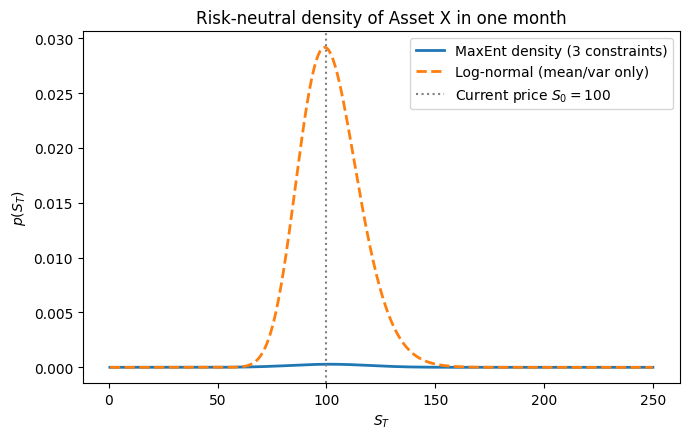

In [ ]:

import matplotlib.pyplot as plt

s_grid = np.linspace(0.5, 250, 2000)
log_p_unnorm = -lam3*np.log(s_grid) - lam1*s_grid - lam2*s_grid**2
p_unnorm = np.exp(log_p_unnorm)
Z_check = Z_u * SCALE   # convert normalization constant back to s-scale
p_maxent = p_unnorm / Z_check

# Compare against the log-normal fit to the SAME mean/variance (ignoring the log-mean constraint)
sigma2_ln = np.log(1 + 196/102**2)
mu_ln = np.log(102) - sigma2_ln/2
p_lognorm = (1/(s_grid*np.sqrt(2*np.pi*sigma2_ln))) * np.exp(-(np.log(s_grid)-mu_ln)**2/(2*sigma2_ln))

plt.figure(figsize=(7,4.5))
plt.plot(s_grid, p_maxent, label='MaxEnt density (3 constraints)', linewidth=2)
plt.plot(s_grid, p_lognorm, '--', label='Log-normal (mean/var only)', linewidth=2)
plt.axvline(100, color='gray', linestyle=':', label='Current price $S_0=100$')
plt.xlabel(r'$S_T$'); plt.ylabel(r'$p(S_T)$')
plt.title('Risk-neutral density of Asset X in one month')
plt.legend()
plt.tight_layout()
plt.show()
